In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
device = torch.device("gpu" if torch.cuda.is_available() else "cpu")

In [3]:
df = pd.read_csv('../data/newport_raw.csv', dtype=str)
df.columns = df.columns.str.lower()

In [5]:
visits_cols = [f"visits_h{x}" for x in range(168)]

tr = df.dropna(subset=visits_cols)    #training set
hold_out_locs = np.random.choice(tr['build_id'], 10)

tr = tr.melt(
  id_vars=['prim_occ', 'sqmeters', 'build_id'], 
  value_vars=visits_cols, 
  var_name='hour_of_week', 
  value_name='visits'
)
tr['hour_of_week'] = tr['hour_of_week'].str.extract(r'(\d+)').astype(int)
tr['sqmeters'] = pd.to_numeric(tr['sqmeters'], errors='coerce')
tr['hour'] = tr['hour_of_week'] % 24
tr['visits'] = tr['visits'].astype("float64").astype("int64")


tr['day'] = tr['hour_of_week'] // 24
tr['sin_dow'] = np.sin(2*np.pi*tr['day']/7)
tr['cos_dow'] = np.cos(2*np.pi*tr['day']/7)


tr['sin_hour'] = np.sin(2*np.pi*tr['hour']/24)
tr['cos_hour'] = np.cos(2*np.pi*tr['hour']/24)

tr['sq_q'] = pd.qcut(tr['sqmeters'], 4, labels=False)

tr['x_prim_occ'] = tr['prim_occ'].astype('category').cat.codes

hold_out = tr[tr['build_id'].isin(hold_out_locs)]
tr = tr[~tr['build_id'].isin(hold_out_locs)]

Text(0.5, 1.0, 'Max visits vs sq meters, "Retail Trade" ')

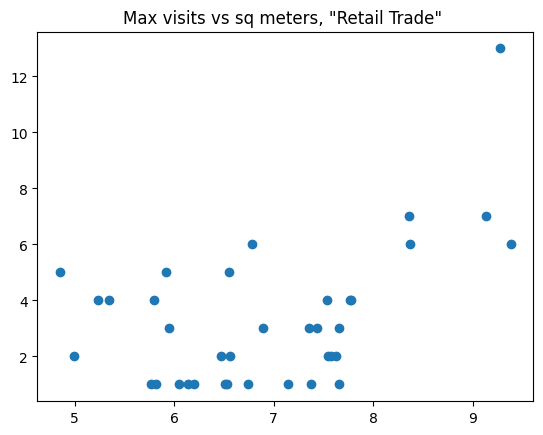

In [6]:
cat = "Retail Trade"
temp = tr.groupby(["prim_occ", "sqmeters"])["visits"].agg(lambda x: np.max(x)).reset_index()
temp["log_sqmeters"] = np.log(temp["sqmeters"])
temp["log_visits"] = np.log(temp["visits"])
plt.scatter(temp[temp["prim_occ"]==cat]["log_sqmeters"], temp[temp["prim_occ"]==cat]["visits"])
plt.title(f"Max visits vs sq meters, \"{cat}\" ")

In [7]:
tr.describe()

,sqmeters,hour_of_week,visits,hour,day,sin_dow,cos_dow,sin_hour,cos_hour,sq_q,x_prim_occ
count,23184.000000,23184.000000,23184.000000,23184.000000,23184.000000,23184.000000,2.318400e+04,2.318400e+04,2.318400e+04,23184.000000,23184.000000
mean,1368.798769,83.500000,0.212992,11.500000,3.000000,0.000000,-5.884412e-17,-4.903677e-18,-9.071802e-17,1.507246,6.876812
std,2204.894829,48.497609,0.714955,6.922336,2.000043,0.707122,7.071220e-01,7.071220e-01,7.071220e-01,1.124498,3.802166
min,92.324590,0.000000,0.000000,0.000000,0.000000,-0.974928,-9.009689e-01,-1.000000e+00,-1.000000e+00,0.000000,0.000000
25%,337.067170,41.750000,0.000000,5.750000,1.000000,-0.781831,-9.009689e-01,-7.071068e-01,-7.071068e-01,0.000000,4.000000
50%,643.129625,83.500000,0.000000,11.500000,3.000000,0.000000,-2.225209e-01,6.123234e-17,-6.123234e-17,2.000000,8.000000
75%,1506.966200,125.250000,0.000000,17.250000,5.000000,0.781831,6.234898e-01,7.071068e-01,7.071068e-01,3.000000,10.000000
max,14440.208000,167.000000,13.000000,23.000000,6.000000,0.974928,1.000000e+00,1.000000e+00,1.000000e+00,3.000000,12.000000


In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula="""
        visits ~
        C(day) +
        sin_hour +
        cos_hour +
        np.log1p(sqmeters) +
        C(prim_occ)
    """,
    data=tr,
    family=sm.families.NegativeBinomial()
).fit()

print(model.summary())

C:\Users\ngoc0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 visits   No. Observations:                23184
Model:                            GLM   Df Residuals:                    23162
Model Family:        NegativeBinomial   Df Model:                           21
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10527.
Date:                Wed, 01 Jul 2026   Deviance:                       11156.
Time:                        12:11:11   Pearson chi2:                 2.91e+04
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1967
Covariance Type:            nonrobust                                         
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [9]:
hold_out

,prim_occ,sqmeters,build_id,hour_of_week,visits,hour,day,sin_dow,cos_dow,sin_hour,cos_hour,sq_q,x_prim_occ
22,Entertainment and Recreation,767.27720,1306283,0,0,0,0,0.000000,1.00000,0.000000,1.000000,2,1
31,Unclassified,586.17975,1306304,0,0,0,0,0.000000,1.00000,0.000000,1.000000,1,12
58,Professional/Technical Services,1197.21460,1307706,0,0,0,0,0.000000,1.00000,0.000000,1.000000,2,8
96,Religious,582.35626,1309366,0,0,0,0,0.000000,1.00000,0.000000,1.000000,1,9
101,Retail Trade,2601.47900,1309578,0,0,0,0,0.000000,1.00000,0.000000,1.000000,3,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24478,Religious,582.35626,1309366,167,0,23,6,-0.781831,0.62349,-0.258819,0.965926,1,9
24483,Retail Trade,2601.47900,1309578,167,0,23,6,-0.781831,0.62349,-0.258819,0.965926,3,10
24504,Retail Trade,641.08234,1311157,167,0,23,6,-0.781831,0.62349,-0.258819,0.965926,1,10
24516,Retail Trade,132.47830,1312153,167,0,23,6,-0.781831,0.62349,-0.258819,0.965926,0,10


In [10]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(hold_out)

mae = mean_absolute_error(
    hold_out["visits"],
    pred
)

mae

0.276344455996759

In [17]:
nonres_to_fill = df[df['occ_cls']!= "Residential"][["build_id", "occ_cls", "prim_occ", "sqmeters"]]
nonres_to_fill['sqmeters'] = nonres_to_fill['sqmeters'].astype("float64")

In [13]:
days = np.arange(7)      # 0-6
hours = np.arange(24)    # 0-23

time_grid = pd.MultiIndex.from_product(
    [days, hours],
    names=['day_of_week', 'hour']
).to_frame(index=False)

In [21]:
prediction_df = nonres_to_fill.merge(
    time_grid,
    how='cross'
)
prediction_df['sin_dow'] = np.sin(2*np.pi*prediction_df['day_of_week']/7)

prediction_df['cos_dow'] = np.cos(2*np.pi*prediction_df['day_of_week']/7)

prediction_df['sin_hour'] = np.sin(2*np.pi*prediction_df['hour']/24)

prediction_df['cos_hour'] = np.cos(2*np.pi*prediction_df['hour']/24)

train_levels = set(tr['prim_occ'].unique())

prediction_df['prim_occ'] = prediction_df['prim_occ'].where(
    prediction_df['prim_occ'].isin(train_levels),
    'Unclassified'
)

In [27]:
prediction_df['expected_visits'] = model.predict(prediction_df)
prediction_df['hour_of_week'] = prediction_df['day_of_week'] * 24 + prediction_df['hour'] 
prediction_df

,build_id,occ_cls,prim_occ,sqmeters,day_of_week,hour,sin_dow,cos_dow,sin_hour,cos_hour,expected_visits,hour_of_week
0,1299962,Unclassified,Unclassified,216.73111,0,0,0.000000,1.00000,0.000000,1.000000,0.017423,0
1,1299962,Unclassified,Unclassified,216.73111,0,1,0.000000,1.00000,0.258819,0.965926,0.015825,1
2,1299962,Unclassified,Unclassified,216.73111,0,2,0.000000,1.00000,0.500000,0.866025,0.015757,2
3,1299962,Unclassified,Unclassified,216.73111,0,3,0.000000,1.00000,0.707107,0.707107,0.017203,3
4,1299962,Unclassified,Unclassified,216.73111,0,4,0.000000,1.00000,0.866025,0.500000,0.020473,4
...,...,...,...,...,...,...,...,...,...,...,...,...
148003,1315403,Commercial,Retail Trade,344.16818,6,19,-0.781831,0.62349,-0.965926,0.258819,0.119377,163
148004,1315403,Commercial,Retail Trade,344.16818,6,20,-0.781831,0.62349,-0.866025,0.500000,0.083661,164
148005,1315403,Commercial,Retail Trade,344.16818,6,21,-0.781831,0.62349,-0.707107,0.707107,0.059279,165
148006,1315403,Commercial,Retail Trade,344.16818,6,22,-0.781831,0.62349,-0.500000,0.866025,0.043476,166


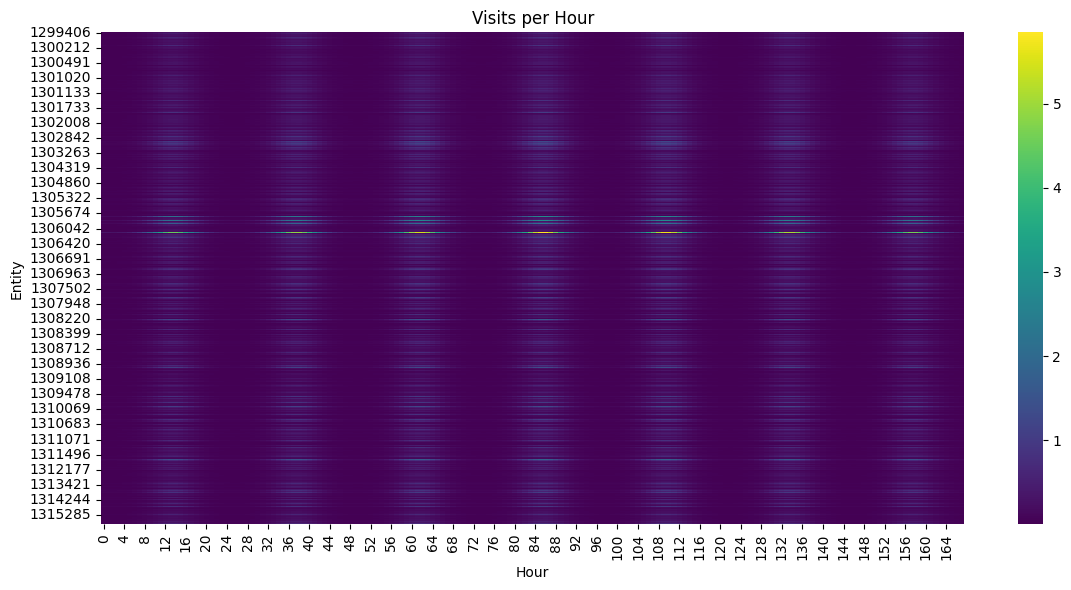

In [34]:
matrix = prediction_df.pivot_table(
    index='build_id',
    columns='hour_of_week',
    values='expected_visits',
    aggfunc='mean'
)

plt.figure(figsize=(12, 6))
sns.heatmap(matrix, cmap='viridis', cbar=True)

plt.xlabel("Hour")
plt.ylabel("Entity")
plt.title("Visits per Hour")
plt.tight_layout()
plt.show()

Too cyclical, let's introduce some noise next

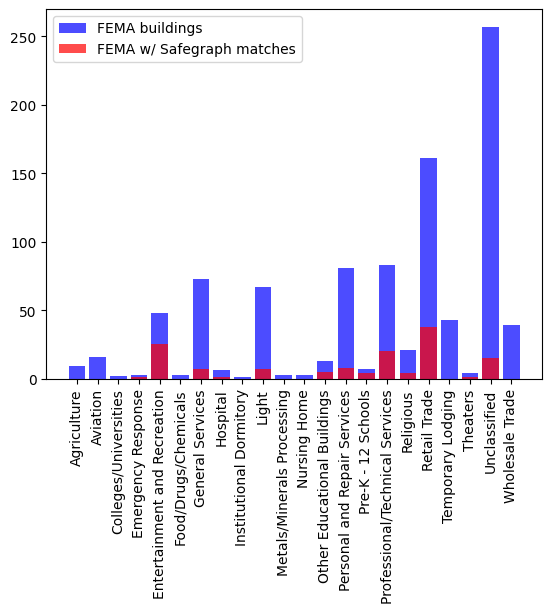

In [79]:
# Counts for full dataframe
df_counts = df['prim_occ'].value_counts().sort_index().drop(['Single Family Dwelling', 'Manufactured Home', 'Multi - Family Dwelling'])

# Counts for subset, aligned to df categories
tr_counts = (
    tr['prim_occ']
    .value_counts()
    .reindex(df_counts.index, fill_value=0)
    .sort_index()
)


x = range(len(df_counts))

plt.bar(x, df_counts.values, label='FEMA buildings', color='b', alpha=0.7)
plt.bar(x, tr_counts.values / 168, label='FEMA w/ Safegraph matches', color='r', alpha=0.7)

plt.xticks(x, df_counts.index, rotation=90)
plt.legend()
plt.show()

In [ ]:
df